### Imports

In [ ]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
# Les outils pour le Deep Learning
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights, vgg16, VGG16_Weights
import torchvision.models as models
import torch.nn as nn
import cv2


# Pour voir l'avancement des calculs
from tqdm import tqdm

In [6]:

def quick_ratio(path):
    """Calcule rapidement le ratio Largeur/Hauteur du contenu utile."""
    with Image.open(path).convert('L') as img:
        arr = np.array(img)
        coords = np.argwhere(arr > 10)
        if coords.size == 0: return 1.0
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        return (x_max - x_min) / (y_max - y_min + 1e-6)

def crop_to_square(img, threshold=10):
    """Recadre au plus près et ajoute du padding noir pour rester carré."""
    img_gray = img.convert('L')
    img_np = np.array(img_gray)
    coords = np.argwhere(img_np > threshold)
    if coords.size == 0: return img.resize((224, 224))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    brain_crop = img.crop((x_min, y_min, x_max, y_max))
    width, height = brain_crop.size
    max_side = max(width, height)
    square_img = Image.new("RGB", (max_side, max_side), (0, 0, 0))
    square_img.paste(brain_crop, ((max_side - width) // 2, (max_side - height) // 2))
    return square_img.resize((224, 224))

### Préparation de l'inventaire des données

In [7]:
def build_inventory(base_path):
    data = []
    for path in base_path.rglob('*.jpg'):
        parts = path.parts
        status = "Labeled" if "avec_labels" in parts else "Unlabeled"
        label = parts[-2] if status == "Labeled" else "Unknown"
        data.append({"path": str(path), "status": status, "label": label})
    return pd.DataFrame(data)

root_dir = Path("../mri_dataset_brain_cancer_oc")
df = build_inventory(root_dir) # On l'appelle 'df' tout simplement

print(f"Inventaire terminé : {len(df)} images trouvées.")

Inventaire terminé : 1506 images trouvées.


Suppression des images trop écrasés

In [ ]:

df['temp_ratio'] = df['path'].apply(quick_ratio)
df_clean = df[df['temp_ratio'] >= 0.50].copy()

print(f"Nettoyage terminé : {len(df) - len(df_clean)} images supprimées.")
print(f"Nombre d'images conservées pour l'IA : {len(df_clean)}")

Nettoyage terminé : 5 images supprimées.
Nombre d'images conservées pour l'IA : 1501


### Définition du pipeline de transformation des données

In [9]:
# C'est la liste des étapes que chaque image va subir
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)), # Les modèles attendent du 224x224
    transforms.ToTensor(),         # Transforme l'image en format mathématique
    # Normalisation standard pour les modèles pré-entraînés
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Création du Dataset PyTorch personnalisé

In [10]:
class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. On récupère le chemin de l'image
        img_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']
        
        # 2. On ouvre l'image et on la force en RGB (3 canaux) 
        # Car ResNet/VGG ont été entraînés sur de la couleur
        img = Image.open(img_path).convert('RGB')
        
        # 3. On applique la recette de la Cellule 3
        if self.transform:
            img = self.transform(img)
            
        return img, label, img_path

# On crée l'objet final
dataset = MRIDataset(dataframe=df, transform=transform_pipeline)

### Extraction de caractéristiques avec ResNet50

In [11]:
### Extraction de caractéristiques avec ResNet50
base_resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
base_resnet.eval() 

# 1. Couche Finale : ResNet possède déjà un GAP à la fin (c'est l'avant-dernier "enfant").
# On prend tout jusqu'à l'avant-dernière couche.
resnet_final = nn.Sequential(*list(base_resnet.children())[:-1])

# 2. Couche Intermédiaire : On ajoute le GAP ici.

resnet_inter = nn.Sequential(
    *list(base_resnet.children())[:7], # On s'arrête au bloc 3
    nn.AdaptiveAvgPool2d((1, 1)),      # On fait la moyenne (GAP)
    nn.Flatten()                       # On transforme en liste plate
)

### Extraction de caractéristiques avec VGG16

In [12]:

# --- ARCHITECTURE 2 : VGG16 ---
base_vgg = vgg16(weights=VGG16_Weights.DEFAULT)
base_vgg.eval()

# Couche A (Finale) : La sortie des couches de convolution (avant les couches denses)
vgg_final = base_vgg.features

# Couche B (Intermédiaire) : On s'arrête au milieu des convolutions
vgg_inter = nn.Sequential(*list(base_vgg.features.children())[:24])

### Création du loader

In [13]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

### Extraction et stockage des vecteurs de caractéristiques (Features)

In [14]:
# Liste pour stocker nos résultats
all_features = []

# On désactive les calculs inutiles pour aller plus vite
with torch.no_grad():
    for imgs, labels, paths in tqdm(dataloader, desc="Extraction en cours"):
        
        # On fait passer les images dans les 4 extracteurs
        # .flatten(1) sert à transformer une matrice en une simple liste de chiffres
        feat_res_fin = resnet_final(imgs).flatten(1)
        feat_res_int = resnet_inter(imgs).flatten(1)
        feat_vgg_fin = vgg_final(imgs).flatten(1)
        feat_vgg_int = vgg_inter(imgs).flatten(1)
        
        # On range tout proprement dans notre liste
        # On repasse en format "Numpy" car c'est plus facile à manipuler après
        for i in range(len(imgs)):
            all_features.append({
                'path': paths[i],
                'label': labels[i],
                'resnet_final': feat_res_fin[i].numpy(),
                'resnet_inter': feat_res_int[i].numpy(),
                'vgg_final': feat_vgg_fin[i].numpy(),
                'vgg_inter': feat_vgg_int[i].numpy()
            })

# On transforme tout ça en un beau tableau Pandas
df_features = pd.DataFrame(all_features)

Extraction en cours:   0%|          | 0/48 [00:00<?, ?it/s]

Extraction en cours: 100%|██████████| 48/48 [05:51<00:00,  7.32s/it]


Visualisation et validation du pipeline de prétraitement

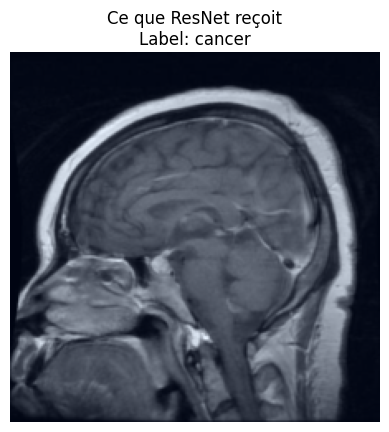

In [ ]:
# On récupère un exemple du dataset (image, label, chemin)
img_t, label, path = dataset[0] 

# Pour l'afficher, on doit faire l'opération inverse de la normalisation
# ou simplement la "dénormaliser" visuellement
img_visu = img_t.permute(1, 2, 0).numpy() # On remet les canaux à la fin (H, W, C)
img_visu = (img_visu - img_visu.min()) / (img_visu.max() - img_visu.min()) # On recale entre 0 et 1

plt.imshow(img_visu)
plt.title(f"Ce que ResNet reçoit\nLabel: {label}")
plt.axis('off')
plt.show()

Analyse des cartes d'activation spatiales (Feature Maps)

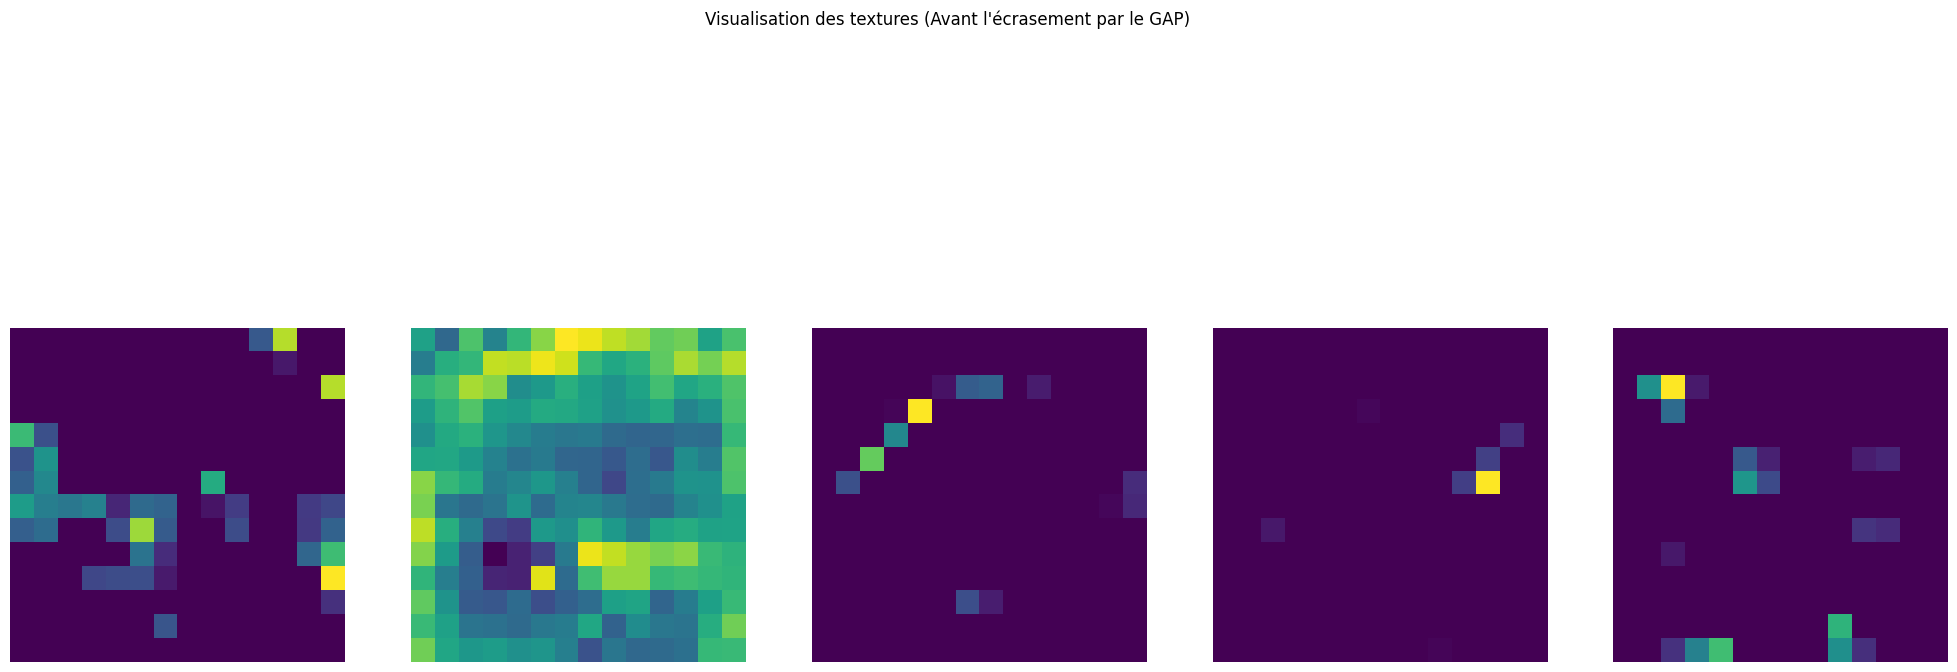

In [16]:
# 1. On crée un modèle de visualisation SANS le GAP pour voir les textures
visualisation_model = nn.Sequential(*list(base_resnet.children())[:7])
visualisation_model.eval()

# 2. On prépare l'image
img_input = img_t.unsqueeze(0) 

# 3. On extrait les features AVANT le pooling
with torch.no_grad():
    features_visu = visualisation_model(img_input)

# 4. On affiche les filtres (qui font maintenant environ 14x14 ou 28x28 pixels)
fig, axes = plt.subplots(1, 5, figsize=(25, 10))
for i in range(5):
    # features_visu[0, i] est maintenant une grille affichable
    axes[i].imshow(features_visu[0, i].numpy(), cmap='viridis')
    axes[i].axis('off')

plt.suptitle("Visualisation des textures (Avant l'écrasement par le GAP)")
plt.show()

Comparaison analytique entre données sources et entrées modèles

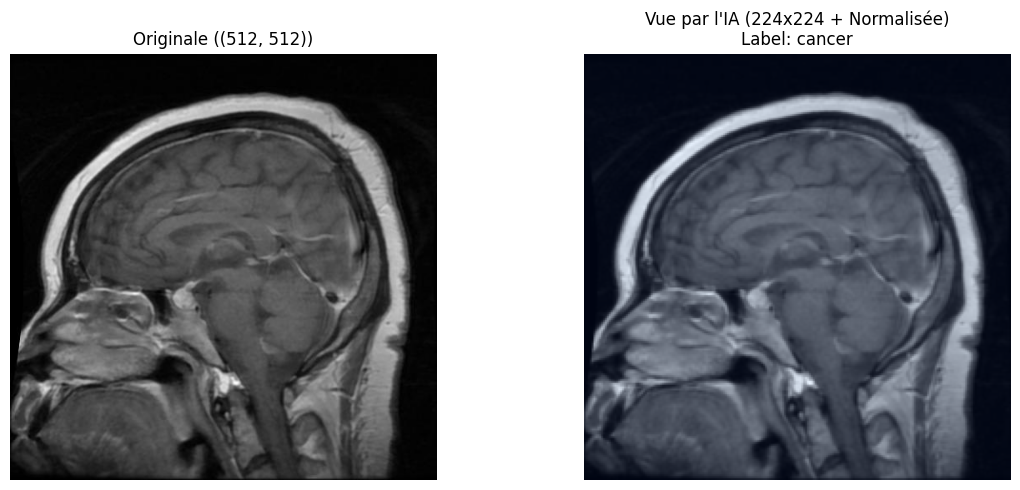

In [ ]:
def visualize_preprocessing(dataset, index=0):
    # 1. On récupère l'image brute (non transformée) et l'image préparée
    # Pour cela, on accède directement au chemin dans le dataframe
    row = dataset.dataframe.iloc[index]
    img_originale = Image.open(row['path']).convert('RGB')
    
    # On récupère l'image transformée par notre dataset PyTorch
    img_tensor, label, _ = dataset[index]
    
    # 2. Préparation pour l'affichage
    # Le tenseur est au format (Canaux, Hauteur, Largeur), on doit le remettre en (H, L, C)
    img_ia = img_tensor.permute(1, 2, 0).numpy()
    
    # On "dénormalise" juste pour l'affichage (remettre les pixels entre 0 et 1)
    img_ia_visu = (img_ia - img_ia.min()) / (img_ia.max() - img_ia.min())

    # 3. Affichage
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(img_originale)
    axes[0].set_title(f"Originale ({img_originale.size})")
    axes[0].axis('off')
    
    axes[1].imshow(img_ia_visu)
    axes[1].set_title(f"Vue par le modèle (224x224 + Normalisée)\nLabel: {label}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Lancement de la visualisation sur la première image
visualize_preprocessing(dataset, index=0)

Analyse des cartes d'activation (Feature Maps) intermédiaires

Taille du tenseur extrait : torch.Size([1, 1024, 14, 14])


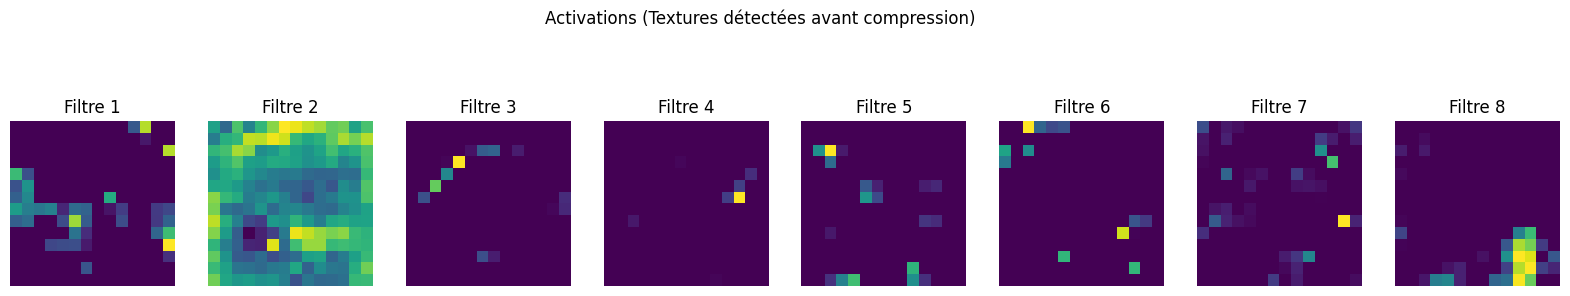

In [18]:
### 1. On définit un extracteur spécifique pour la VISUALISATION (Sans le GAP)
# On s'arrête exactement au même endroit ([:7]), mais on ne met pas de Pooling à la fin.
resnet_visu = nn.Sequential(*list(base_resnet.children())[:7])
resnet_visu.eval()

### 2. On met à jour la fonction pour qu'elle soit plus robuste
def plot_feature_maps(model_to_use, dataset, index=0):
    img_tensor, _, _ = dataset[index]
    img_batch = img_tensor.unsqueeze(0) 
    
    with torch.no_grad():
        features = model_to_use(img_batch)
    
    # Debug : on affiche la taille pour comprendre
    print(f"Taille du tenseur extrait : {features.shape}") 
    # Si c'est [1, 1024, 1, 1], imshow va planter.
    # Si c'est [1, 1024, 14, 14], imshow va fonctionner.

    fig, axes = plt.subplots(1, 8, figsize=(20, 4))
    for i in range(8):
        f_map = features[0, i].numpy()
        axes[i].imshow(f_map, cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f"Filtre {i+1}")
        
    plt.suptitle("Activations (Textures détectées avant compression)")
    plt.show()

# 3. ON APPELLE AVEC LE MODÈLE DE VISUALISATION
plot_feature_maps(resnet_visu, dataset, index=0)

Sauvegarde au format Pickle (conserve les tableaux numpy intacts)


In [ ]:
df_features.to_pickle("../features/features_mri_baseline.pkl")

print("Fichier 'features_mri_baseline.pkl' sauvegardé.")


Fichier 'features_mri_baseline.pkl' sauvegardé.


Réalisation d'un CLAHE

In [20]:
class ApplyCLAHE(object):
    def __init__(self, clip_limit=3.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        img_clahe = self.clahe.apply(img_gray)
        img_final = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_final)

Instanciation des architectures d'extraction de caractéristiques

In [21]:
# 1. On charge le modèle complet
full_model = models.resnet50(pretrained=True)

# 2. On crée le modèle "Intermédiaire" 
# On s'arrête juste après la Layer 3 (là où les textures sont les plus riches)
intermediate_layer_model = nn.Sequential(*list(full_model.children())[:-3])

# 3. Passage en mode évaluation
intermediate_layer_model.eval()

c:\Users\ethan\Documents\OpenClassrooms\Approche_semi_supervise\venv_brain\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ethan\Documents\OpenClassrooms\Approche_semi_supervise\venv_brain\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


Implémentation de la classe d'accès aux données (Dataset)

In [22]:
class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, row['label'], row['path']

Pipeline de prétraitement avec amélioration de contraste (CLAHE) et extraction de caractéristiques

In [ ]:
# 1. On définit le pipeline d'extraction avec CLAHE
# C'est ici qu'on applique le filtre à TOUT le monde
transform_clahe = transforms.Compose([
    transforms.Resize((224, 224)),
    ApplyCLAHE(clip_limit=3.0), # Le boost de texture
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. On crée le Dataset et le Loader
dataset_clahe = MRIDataset(df_features, transform=transform_clahe)
loader = DataLoader(dataset_clahe, batch_size=32, shuffle=False)

# 3. Extraction via la couche intermédiaire (la gagnante)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
intermediate_layer_model.to(device)
intermediate_layer_model.eval()

features_clahe = []

print("Extraction CLAHE en cours")
with torch.no_grad():
    for imgs, _, _ in loader:
        imgs = imgs.to(device)
        output = intermediate_layer_model(imgs)
        output = torch.flatten(output, 1)
        features_clahe.extend(output.cpu().numpy())

# 4. On enregistre dans un nouveau fichier PKL
df_features['resnet_inter_clahe'] = features_clahe
df_features.to_pickle("../features/features_mri_clahe.pkl")
print("Fichier 'features_mri_clahe.pkl' généré avec succès !")

Extraction CLAHE en cours... (Prépare-toi un café)
Fichier 'features_mri_clahe.pkl' généré avec succès !


Pipeline hybride : Prétraitement géométrique, amélioration de contraste et extraction finale

In [ ]:
class MRIHybridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.clahe = ApplyCLAHE(clip_limit=2.0) # On utilise ta classe existante

    def __len__(self): return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = crop_to_square(img) # Crop & Pad d'abord
        img = self.clahe(img)      # CLAHE ensuite
        if self.transform: img = self.transform(img)
        return img, row['label'], row['path']

# 1. Pipeline
transform_final = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Dataset & Loader
dataset_hybrid = MRIHybridDataset(df_clean, transform=transform_final)
loader_hybrid = DataLoader(dataset_hybrid, batch_size=32, shuffle=False)

# 3. Boucle d'extraction
features_hybrid = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_inter.to(device)

print("Lancement de l'extraction Hybride finale...")
for imgs, labels, paths in tqdm(loader_hybrid):
    with torch.no_grad():
        imgs = imgs.to(device)
        output = resnet_inter(imgs).flatten(1)
        for i in range(len(imgs)):
            features_hybrid.append({
                'path': paths[i], 'label': labels[i],
                'resnet_inter_hybrid': output[i].cpu().numpy()
            })

# 4. Sauvegarde
pd.DataFrame(features_hybrid).to_pickle("../features/features_mri_hybrid.pkl")
print("TERMINÉ : Le fichier features_mri_hybrid.pkl est prêt.")

Lancement de l'extraction Hybride finale...


100%|██████████| 47/47 [01:06<00:00,  1.42s/it]

TERMINÉ : Le fichier features_mri_hybrid.pkl est prêt.
